In [3]:
print("hello world")

hello world


In [4]:
import pandas as pd

In [5]:
import yfinance as yf

apple = yf.Ticker('AAPL')

data = apple.history(period='10y')

print(data)

                                 Open        High         Low       Close  \
Date                                                                        
2016-05-09 00:00:00-04:00   21.190922   21.366373   21.097499   21.143072   
2016-05-10 00:00:00-04:00   21.266113   21.320798   20.988124   21.286619   
2016-05-11 00:00:00-04:00   21.300291   21.320798   21.067874   21.079268   
2016-05-12 00:00:00-04:00   21.127122   21.140793   20.386579   20.584816   
2016-05-13 00:00:00-04:00   20.507344   20.887868   20.507344   20.625830   
...                               ...         ...         ...         ...   
2026-05-04 00:00:00-04:00  279.660004  280.630005  274.859985  276.829987   
2026-05-05 00:00:00-04:00  276.929993  284.570007  276.500000  284.179993   
2026-05-06 00:00:00-04:00  281.920013  288.029999  281.070007  287.510010   
2026-05-07 00:00:00-04:00  289.269989  292.130005  285.779999  287.440002   
2026-05-08 00:00:00-04:00  290.109985  294.554993  290.000000  293.359985   

<function matplotlib.pyplot.show(close=None, block=None)>

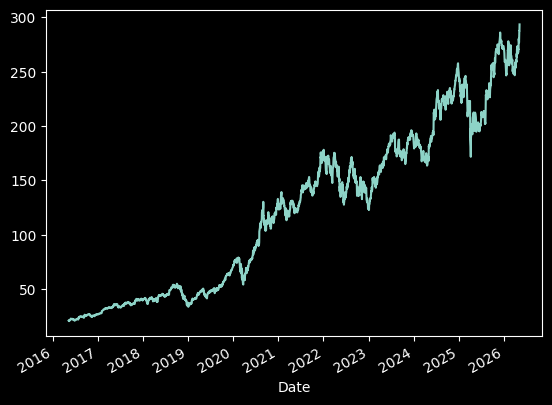

In [6]:
import matplotlib.pyplot as plt

data['Close'].plot()

plt.show

# Why did Apple's stock price rise so much between 2020 and 2026?

The most significant factors affecting a company's stock price are its company earnings and financial performance . These are some metrics that represent that:

- Revenue growth
- Profit margins
- Earnings per share (EPS)
- Cash flow
- Debt levels


## Let's begin with an analysis of Apple's revenue growth and why this may explain its stock price

In [7]:
apple.financials

,2025-09-30,2024-09-30,2023-09-30,2022-09-30,2021-09-30
Tax Effect Of Unusual Items,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
Tax Rate For Calcs,1.560000e-01,2.410000e-01,1.470000e-01,1.620000e-01,NaN
Normalized EBITDA,1.447480e+11,1.346610e+11,1.258200e+11,1.305410e+11,NaN
Net Income From Continuing Operation Net Minority Interest,1.120100e+11,9.373600e+10,9.699500e+10,9.980300e+10,NaN
Reconciled Depreciation,1.169800e+10,1.144500e+10,1.151900e+10,1.110400e+10,NaN
Reconciled Cost Of Revenue,2.209600e+11,2.103520e+11,2.141370e+11,2.235460e+11,NaN
EBITDA,1.447480e+11,1.346610e+11,1.258200e+11,1.305410e+11,NaN
EBIT,1.330500e+11,1.232160e+11,1.143010e+11,1.194370e+11,NaN
Net Interest Income,NaN,NaN,-1.830000e+08,-1.060000e+08,1.980000e+08
Interest Expense,NaN,NaN,3.933000e+09,2.931000e+09,2.645000e+09


In [8]:

pd.options.display.float_format = '{:,.2f}'.format
revenue = apple.financials.loc['Total Revenue']
print(revenue)

2025-09-30   416,161,000,000.00
2024-09-30   391,035,000,000.00
2023-09-30   383,285,000,000.00
2022-09-30   394,328,000,000.00
2021-09-30                  NaN
Name: Total Revenue, dtype: float64


In [9]:
rev_growth = ((revenue.iloc[0] - revenue.iloc[3])/revenue.iloc[3])*100
print(rev_growth)

5.536761274877767


## Total revenue doesn't seem to have differed that drastically between 2022 and 2025.

There has only been a **5.5% growth rate** between 2025 and 2022.

Looking at profit margin next

In [10]:
net_income = apple.financials.loc['Net Income']
print(net_income)

profit_margin = net_income/revenue
print(profit_margin)

2025-09-30   112,010,000,000.00
2024-09-30    93,736,000,000.00
2023-09-30    96,995,000,000.00
2022-09-30    99,803,000,000.00
2021-09-30                  NaN
Name: Net Income, dtype: float64
2025-09-30   0.27
2024-09-30   0.24
2023-09-30   0.25
2022-09-30   0.25
2021-09-30    NaN
dtype: float64


## profit margins also look stable

- I may be jumping the gun here but what if apple's drastic growth doesn't have anything to do with its company financials...

<u>Next Step: </u>
I will look at its earnings per share, cash flow and debt levels and if there is no significant change in these metrics i will conclude that Apple's company financials are not the main cause for the change in stock price.

In [11]:
shares = apple.info['sharesOutstanding']
#EPS means earnings per share

eps = net_income/shares

print(eps)


2025-09-30   7.63
2024-09-30   6.38
2023-09-30   6.60
2022-09-30   6.80
2021-09-30    NaN
Name: Net Income, dtype: float64


EPS only showed a notable change between 2024 and 2025

In [12]:
# ocf is operating cash flow
cashflow = apple.cashflow
print(cashflow)


                                                        2025-09-30  \
Free Cash Flow                                   98,767,000,000.00   
Repurchase Of Capital Stock                     -90,711,000,000.00   
Repayment Of Debt                               -10,932,000,000.00   
Issuance Of Debt                                  4,481,000,000.00   
Issuance Of Capital Stock                                      NaN   
Capital Expenditure                             -12,715,000,000.00   
Interest Paid Supplemental Data                                NaN   
Income Tax Paid Supplemental Data                43,369,000,000.00   
End Cash Position                                35,934,000,000.00   
Beginning Cash Position                          29,943,000,000.00   
Changes In Cash                                   5,991,000,000.00   
Financing Cash Flow                            -120,686,000,000.00   
Cash Flow From Continuing Financing Activities -120,686,000,000.00   
Net Other Financing 

In [13]:
fcf = cashflow.loc["Free Cash Flow"]

fcf_margin = (fcf/revenue)*100

print(fcf_margin)

2025-09-30   23.73
2024-09-30   27.83
2023-09-30   25.98
2022-09-30   28.26
2021-09-30     NaN
dtype: float64


Free cash flow margin also seems to be the same

In [15]:
operating_income = apple.income_stmt.loc['Operating Income']

interest_expense = abs(apple.income_stmt.loc['Interest Expense'])

print(operating_income)

print(interest_expense)

2025-09-30   133,050,000,000.00
2024-09-30   123,216,000,000.00
2023-09-30   114,301,000,000.00
2022-09-30   119,437,000,000.00
2021-09-30                  NaN
Name: Operating Income, dtype: float64
2025-09-30                NaN
2024-09-30                NaN
2023-09-30   3,933,000,000.00
2022-09-30   2,931,000,000.00
2021-09-30   2,645,000,000.00
Name: Interest Expense, dtype: float64


In [16]:
interest_coverage = operating_income / interest_expense

print(interest_coverage.round(2))

2025-09-30     NaN
2024-09-30     NaN
2023-09-30   29.06
2022-09-30   40.75
2021-09-30     NaN
dtype: float64


the operating income seems to have steadily increased and the interst expense have increased more significantly over the 2021-2023 period. However the interest coverage ratio is shown to have declined a lot between 2022-2023 which really is evidence against Apple's stock price increase.